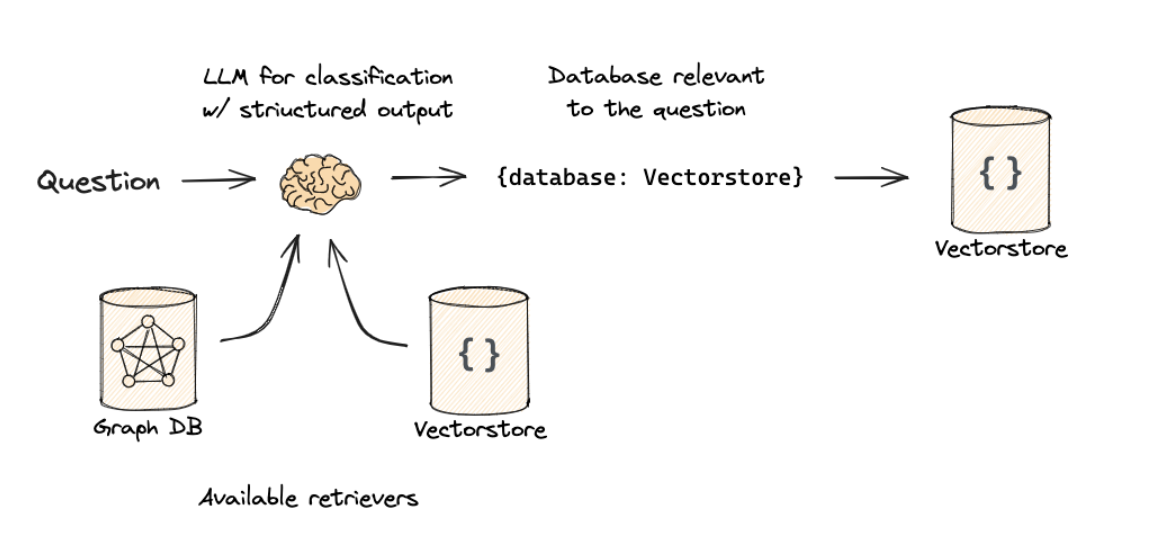

In [16]:
from typing import Literal, Annotated
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI 

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Annotated[Literal["python", "js", "golang"], Field(..., description="Pick the programming language used in the question.")]

In [17]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
structured_router = llm.with_structured_output(RouteQuery)

In [18]:
router_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert router. Route the question to python, js, or golang."),
    ("human", "{question}"),
])

router_chain = router_prompt | structured_router

In [ ]:
# Can place the respective retriever here for each language
python_chain = ChatPromptTemplate.from_template("Python Expert: {question}") | llm | StrOutputParser()
js_chain     = ChatPromptTemplate.from_template("JS Expert: {question}")     | llm | StrOutputParser()
golang_chain = ChatPromptTemplate.from_template("Go Expert: {question}")     | llm | StrOutputParser()

route_map = {
    "python": python_chain,
    "js": js_chain,
    "golang": golang_chain
}

In [20]:
question = "How do I create a slice in Go?"

decision = router_chain.invoke({"question": question})
decision    # Pydantic model

RouteQuery(datasource='golang')

In [21]:
final_response = route_map[decision.datasource].invoke({"question": question})
final_response

'As a Go Expert, understanding how to create and manage slices is fundamental to writing efficient and idiomatic Go code. Slices are a powerful, flexible, and commonly used data structure in Go, built on top of arrays.\n\nLet\'s break down the various ways to create slices, along with their implications for length, capacity, and the underlying array.\n\n---\n\n### Key Concepts First: Length and Capacity\n\nBefore diving into creation methods, it\'s crucial to understand `len` and `cap`:\n\n*   **Length (`len(s)`):** The number of elements currently in the slice. This is the number of elements you can access directly (e.g., `s[0]` to `s[len(s)-1]`).\n*   **Capacity (`cap(s)`):** The maximum number of elements the slice can hold without reallocating its underlying array. It\'s the length of the underlying array, starting from the slice\'s first element.\n\n---\n\n### Methods to Create a Slice\n\nHere are the primary ways to create slices in Go:\n\n1.  **Using a Slice Literal (Composite L